# Продвинутые архитектуры рекуррентных нейронных сетей (xLSTM)

Рекомендуется изучить [обзор этой архитектуры от Data Secrets](https://datasecrets.ru/articles/10)

## Введение

Простые RNN обрабатывают последовательности поддерживая скрытое состояние $h_t$, которое обновляется на каждом временном шаге $t$. Это выглядит так:

$$h_t = \tanh(W_{hh}h_{t-1} + W_{xh}x_t + b_h)$$

где $x_t$ — это вход на шаге $t$, а $W_{hh}$ и $W_{xh}$ — матрицы весов. Во время обучения с использованием алгоритма обратного распространения ошибки во времени (Backpropagation Through Time, BPTT) градиент функции потерь $L$ по отношению к скрытому состоянию на далеком прошлом шаге $k$ ($k \ll t$) вычисляется с помощью цепного правила:

$$\frac{\partial L}{\partial h_k} = \frac{\partial L}{\partial h_t} \frac{\partial h_t}{\partial h_{t-1}} \frac{\partial h_{t-1}}{\partial h_{t-2}} \cdots \frac{\partial h_{k+1}}{\partial h_k}$$

**Ключевая проблема** заключается в члене $\frac{\partial h_t}{\partial h_{t-1}}$. Его вычисление включает в себя умножение на весовую матрицу $W_{hh}$ и производную функции активации ($\tanh'$).

Архитектура LSTM предложена в 1997 году ([Sepp Hochreiter, Schmidhuber](https://www.researchgate.net/publication/13853244_Long_Short-Term_Memory)) как решение этой проблемы. Центральным элементом стала **карусель постоянной ошибки** (Constant Error Carousel, CEC).

Составляющие:
- cкрытое состояние ($h_t$), долгосрочная память
- cостояние ячейки ($c_t$), краткосрочная память
- гейты, с помощью которых контролируем, какую информацию оставляем или удаляем

> Идея заключается в создании пути, на котором градиент двигается назад во времени практически без изменений. Это достигается за счет введения состояния ячейки (cell state), обозначаемого как $c_t$ (ранее в лекции как $S_t$)

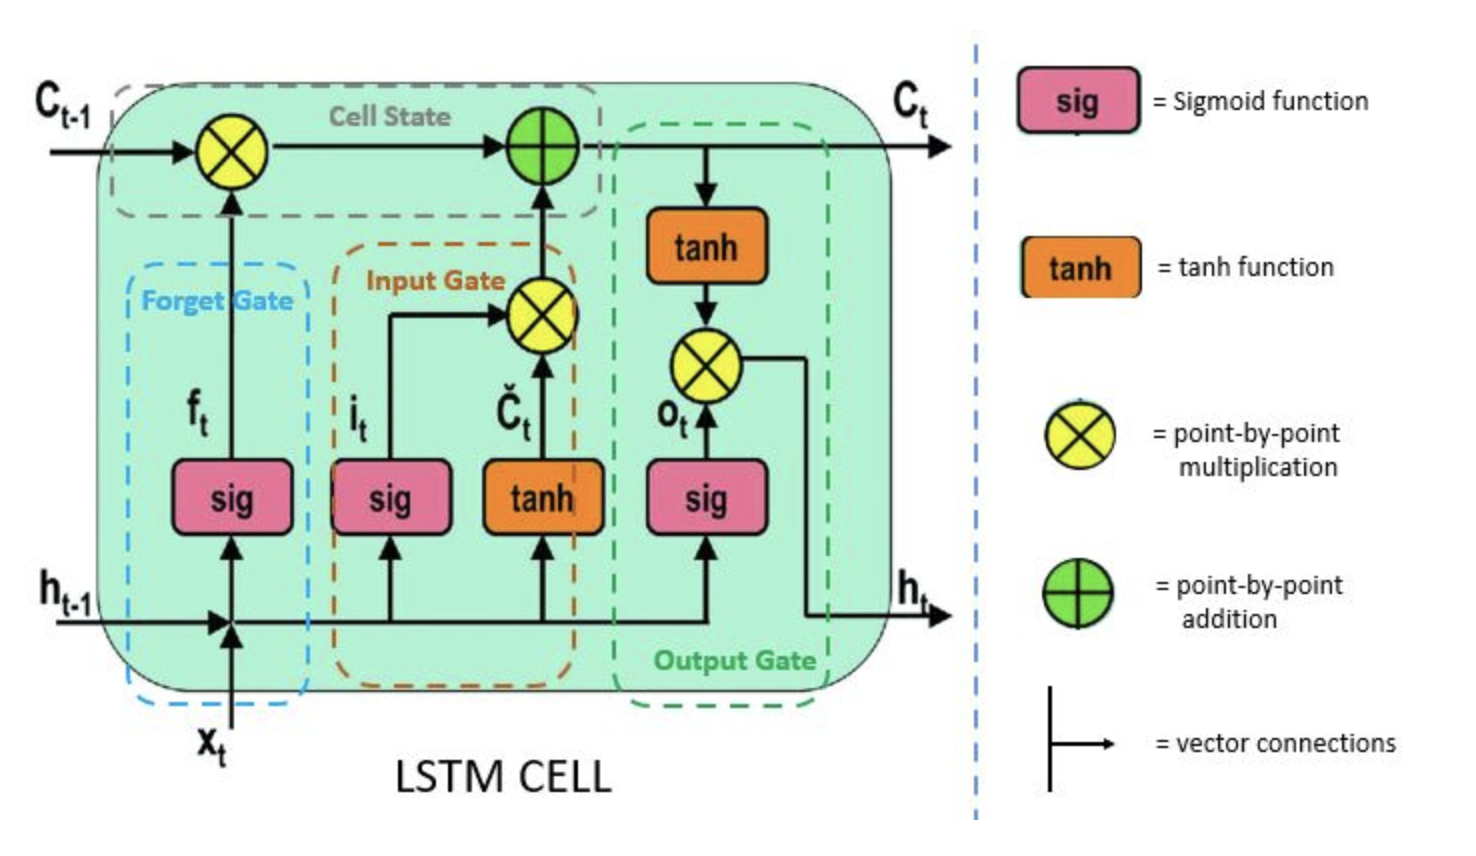

## Механизм CEC

Уравнение обновления состояния ячейки в LSTM:

$$
c_t = \underbrace{(f_t \odot c_{t-1})}_{\text{старая информация}} + \underbrace{(i_t \odot \tilde{c}_t)}_{\text{новая информация}}
$$

Здесь $\odot$ — произведение Адамара, $f_t$ — вентиль забывания (forget gate), $i_t$ — вентиль входа (input gate), а $\tilde{c}_t$ — кандидат на новое состояние.

Вспоминаем проблему классических RNN:

$$
\frac{\partial h_i}{\partial h_{i-1}} = \tanh'(\dots) \cdot W_{hh}
$$

Ключевая разница в сложении, а не в *умножении* внутри $\tanh$:

$$
\frac{\partial c_i}{\partial c_{i-1}} = \frac{\partial}{\partial c_{i-1}} [f_i \odot c_{i-1} + i_i \odot \tilde{c}_i]
$$

Раскрываем производную, при этом не смотрим на $i_t$ и $\tilde{c}_t$ (там будет затухающий путь):

$$
\frac{\partial c_i}{\partial c_{i-1}} \approx \frac{\partial}{\partial c_{i-1}} [f_i \odot c_{i-1}]
$$

Поскольку $f_i$ не зависит от $c_{i-1}$ напрямую, то производная этого поэлементного произведения:

$$
\frac{\partial c_i}{\partial c_{i-1}} \approx f_i
$$

> Если сеть хочет **помнить** информацию из шага $k$, она *выучивается* устанавливать $f_i = 1$ для всех шагов между $k$ и $t$

## Новые ячейки

### sLSTM

В мае 2024 года команда под руководством Sepp Hochreiter опубликовала [новое исследование](https://arxiv.org/abs/2405.04517). Представлено семейство моделей xLSTM, построенное на двух инновациях:

- экспоненциальное гейтирование (Exponential Gating)

- модифицированные структуры памяти (Scalar и Matrix Memory)

> **Два новых типа рекуррентных ячеек:** sLSTM (скалярная LSTM) и mLSTM (матричная LSTM)

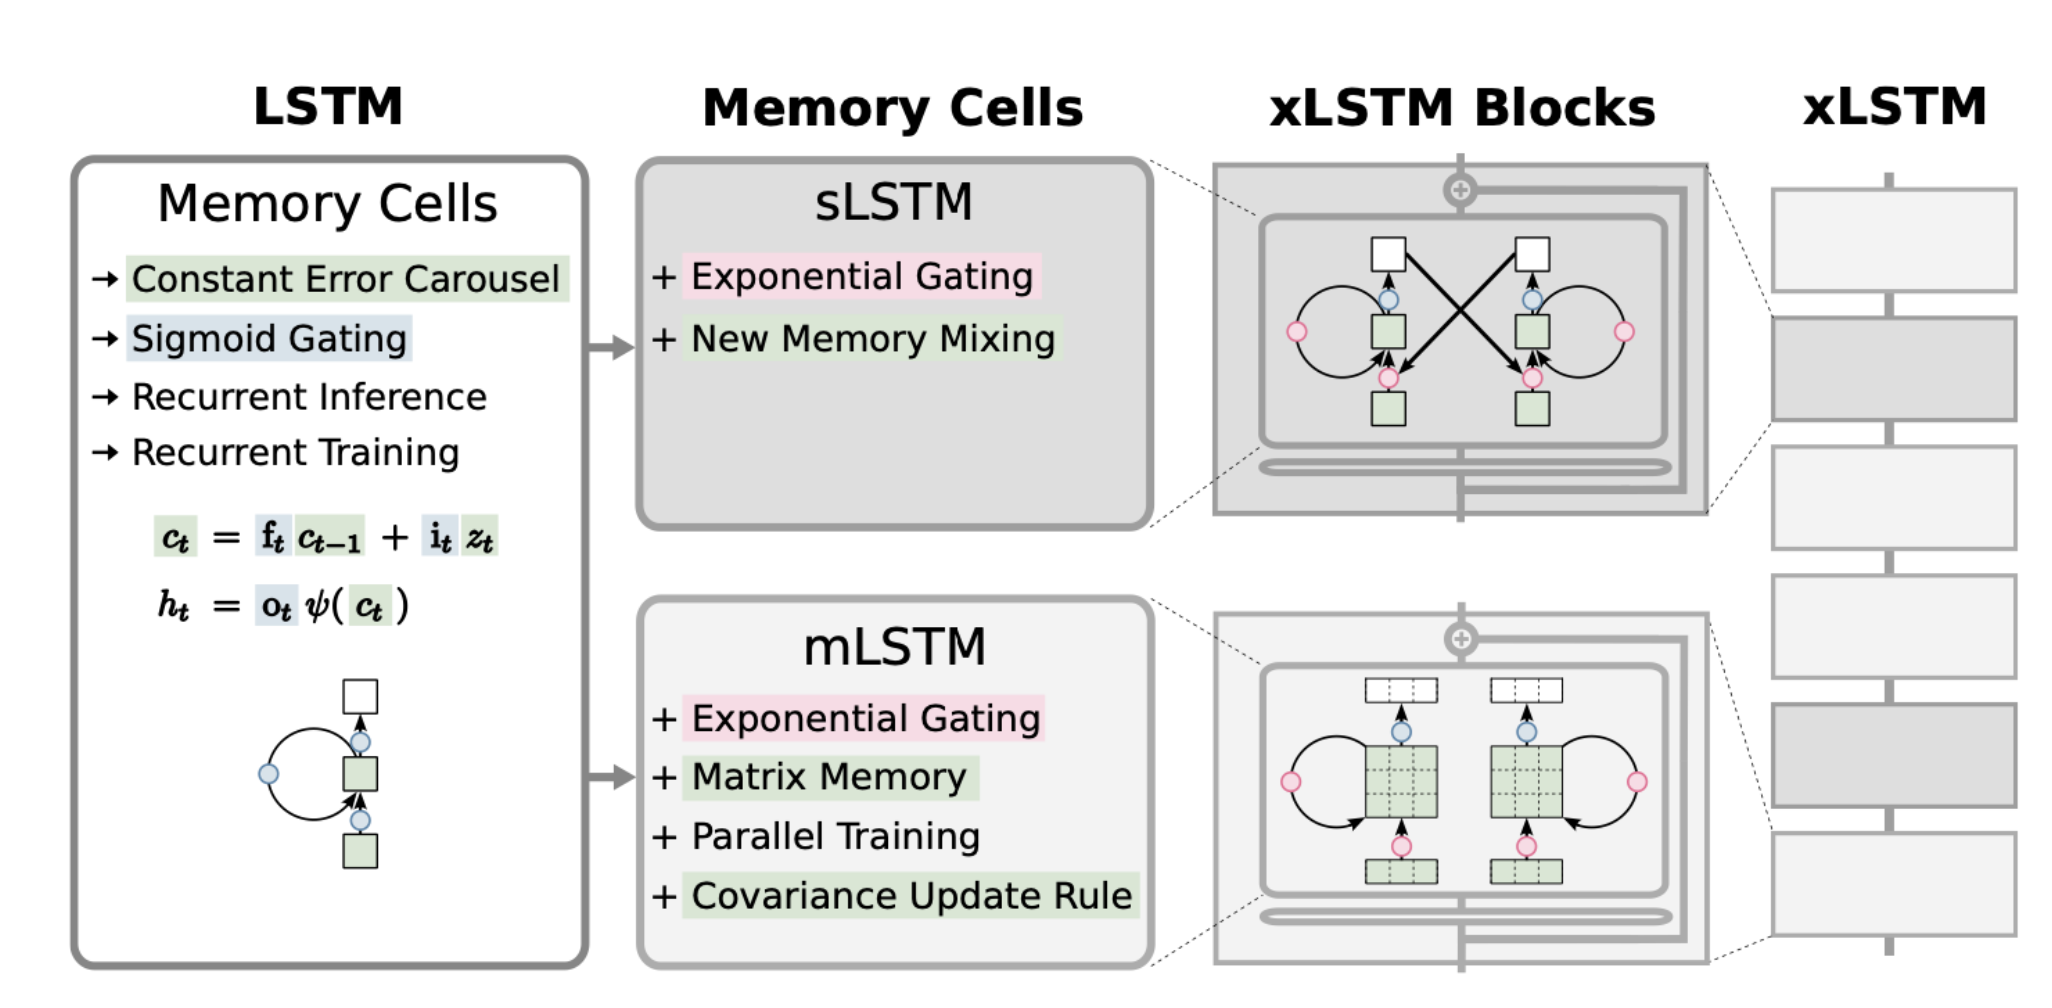

Основное отличие sLSTM заключается в замене сигмоидных функций активации $\sigma(\cdot)$ в вентилях входа и забывания на экспоненциальную функцию $\exp(\cdot)$.

Использование функции $\exp(\cdot)$ создает проблему: значения могут быстро расти, приводя к нестабильности обучения. Для преодоления этой сложности вводятся два состояния (наряду с $c_t$ и $h_t$).

Состояние **нормализатора** обновляется по формуле:

$$n_t = f_t n_{t-1} + i_t$$

Отслеживает сумму всех входных и забывающих вентилей, которые внесли вклад в текущее состояние ячейки. Скрытое состояние вычисляется как нормализованное состояние ячейки:

$$\tilde{h}_t = c_t / n_t$$

Состояние **стабилизатора** контролирует экспоненту от "взрыва":

$$m_t = \max(\log(f_t) + m_{t-1}, \log(i_t))$$
$$i_t' = \exp(\log(i_t) - m_t)$$
$$f_t' = \exp(\log(f_t) + m_{t-1} - m_t)$$

> Поскольку $m_t$ — максимум из двух частей, то обе разности в скобках $(\dots - m_t)$ гарантированно будут отрицательными или нулем

### mLSTM

Ключевое изменение — переход от векторного состояния ячейки $c_t$ **к матричному состоянию** $C_t \in \mathbb{R}^{d \times d}$.

Вентили и входы в mLSTM зависят только от текущего входа $x_t$. Это делает mLSTM полностью распараллеливаемой в ходе обучения.

На каждом шаге модель вычисляет три вектора из входа $x_t$: запрос (query, $q_t$), ключ (key, $k_t$) и значение (value, $v_t$). Авторы явно чем-то вдохновились :)

Вычисляются с помощью обучаемых линейных преобразований, которые не зависят от $t$:

$$
q_t = W_q x_t + b_q
$$

$$
k_t = W_k x_t + b_k
$$

$$
v_t = W_v x_t + b_v
$$

Память обновляется с помощью **ковариационного правила обновления**, которое использует внешнее произведение ключа и значения:

$$C_t = f_t C_{t-1} + i_t v_t k_t^T$$

Эта операция записывает ассоциацию между ключом $k_t$ и значением $v_t$ в матрицу памяти $C_t$. Матрица $C_t$ становится суммой всех прошлых ассоциаций ключ-значение, взвешенных вентилями. Здесь $f_t$ и $i_t$ являются скалярами (применяется сигмоида как обычной LSTM). Выход блока вычисляется как $C_t q_t$.

Раскроем выражение:

$$C_t q_t = \left( \sum_{j=1}^{t} (\dots) v_j k_j^T \right) q_t = \sum_{j=1}^{t} (\dots) v_j (k_j^T q_t)$$

$$(\dots) = i_j \cdot \prod_{m=j+1}^{t} f_m$$

Вес для каждого значения $v_j$ определяется скалярным произведением его ключа $k_j$ и текущего запроса $q_t$. **Эта формула параллелится.**

Не забываем о нормализации:

$$
\tilde{h}_t = C_t q_t / \max \{ |n_t^\top q_t|, 1 \}
$$

## Остаточные блоки и выводы

Архитектура xLSTM — это глубокая сеть, созданная путем стекирования блоков xLSTM. Каждый блок содержит слой sLSTM или mLSTM, за которым следуют слои прямой связи (feed-forward), нормализация (Layer Normalization) и остаточные связи.

**xLSTM — это:**
- асимптотика O(n) и возможность распараллеливания при обучении
- асимптотика O(1) при инференсе для каждого токена

Для sLSTM в оригинальном исследовании предложены следующие блоки:

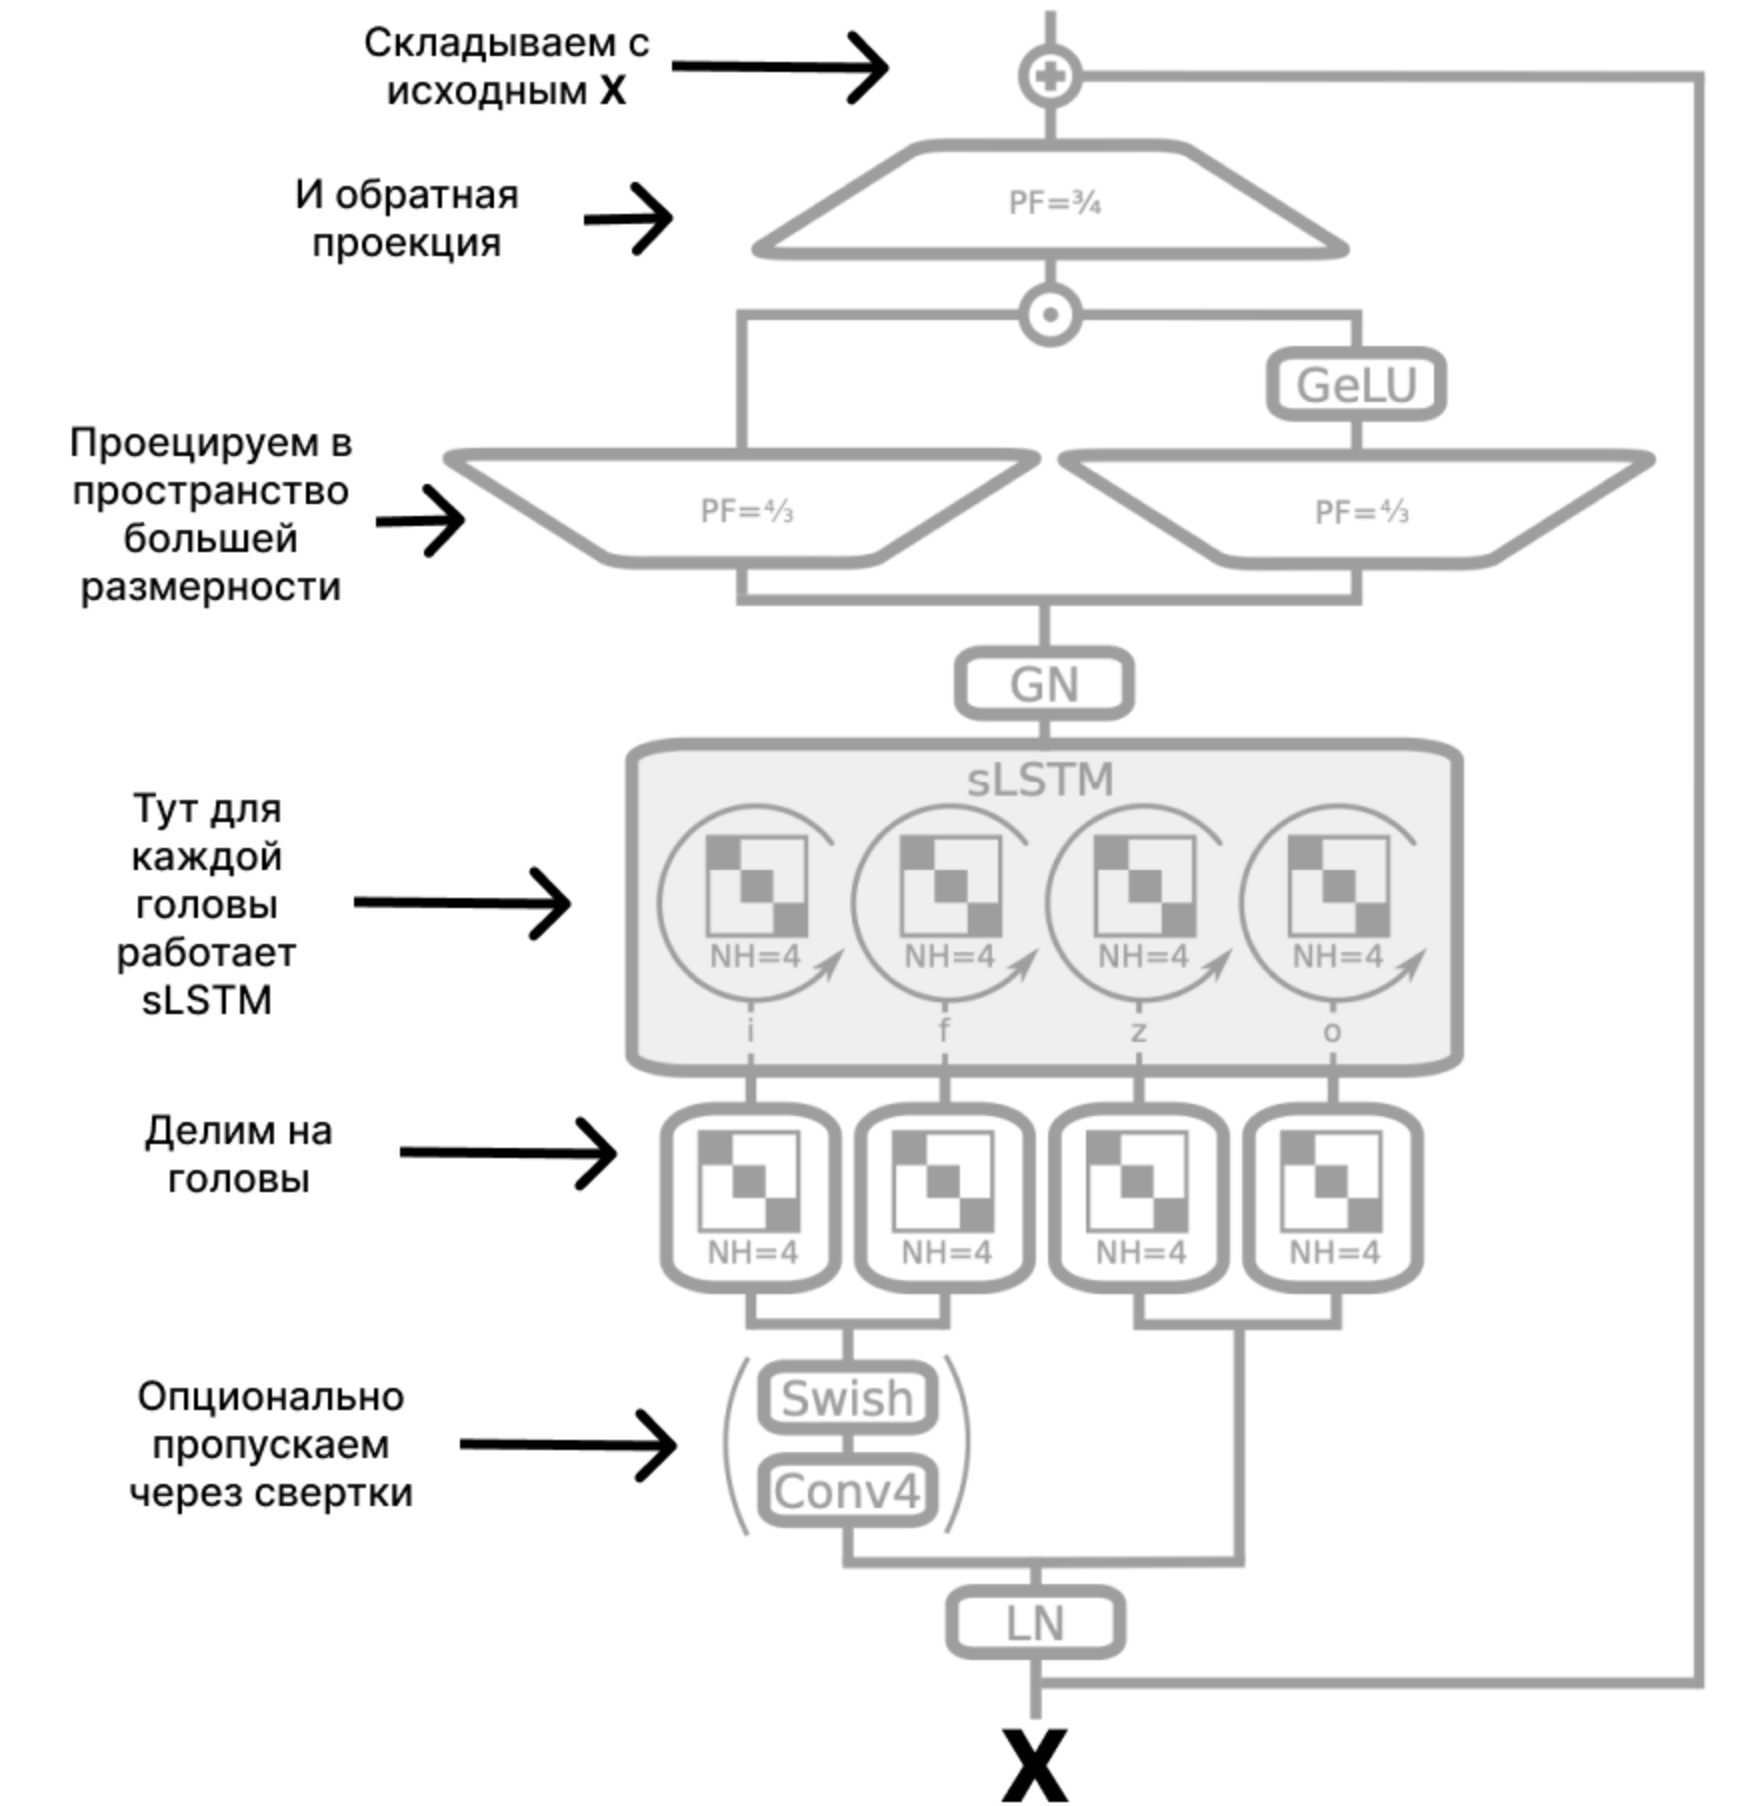

Здесь [GELU (Gaussian Error Linear Unit)](https://www.ultralytics.com/ru/glossary/gelu-gaussian-error-linear-unit): 
$$\text{GELU}(x) = x \cdot \Phi(x)$$
$$\text{GELU}(x) \approx 0.5x \left(1 + \tanh\left[\sqrt{\frac{2}{\pi}} \left(x + 0.044715x^3\right)\right]\right)$$

Для mLSTM все то же самое, **но в другом порядке**. Отражаем входы в пространство большей размерности -> делим на головы -> пропускаем через mLSTM -> объединяем по GroupNorm -> проецируем обратно в родную размерность -> складываем со входами.

Падение **перплексии** на [наборе данных SlimPajama](https://www.cerebras.ai/blog/slimpajama-a-627b-token-cleaned-and-deduplicated-version-of-redpajama): 


$$\text{PPL} = e^{\text{Cross-Entropy Loss}}$$

> Перплексию можно понимать как эффективное количество вариантов, из которых модель выбирает на каждом шаге. Если перплексия модели равна 100, значит ее **неуверенность при предсказании** следующего токена эквивалентна выбору одного из 100 равновероятных слов


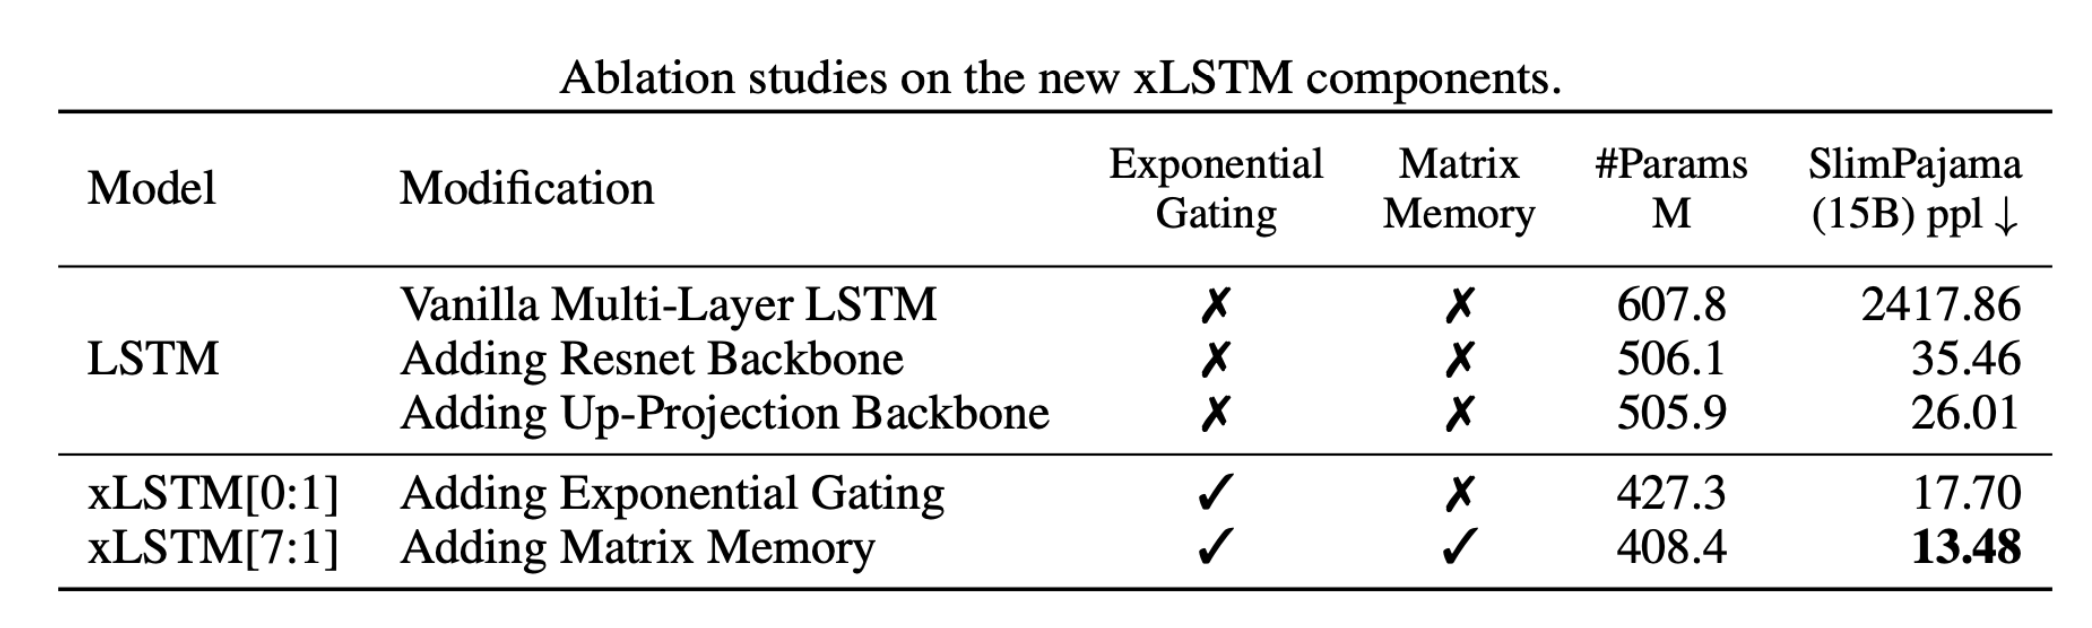

Модель сопоставима с GPT-3 на 350М параметров:

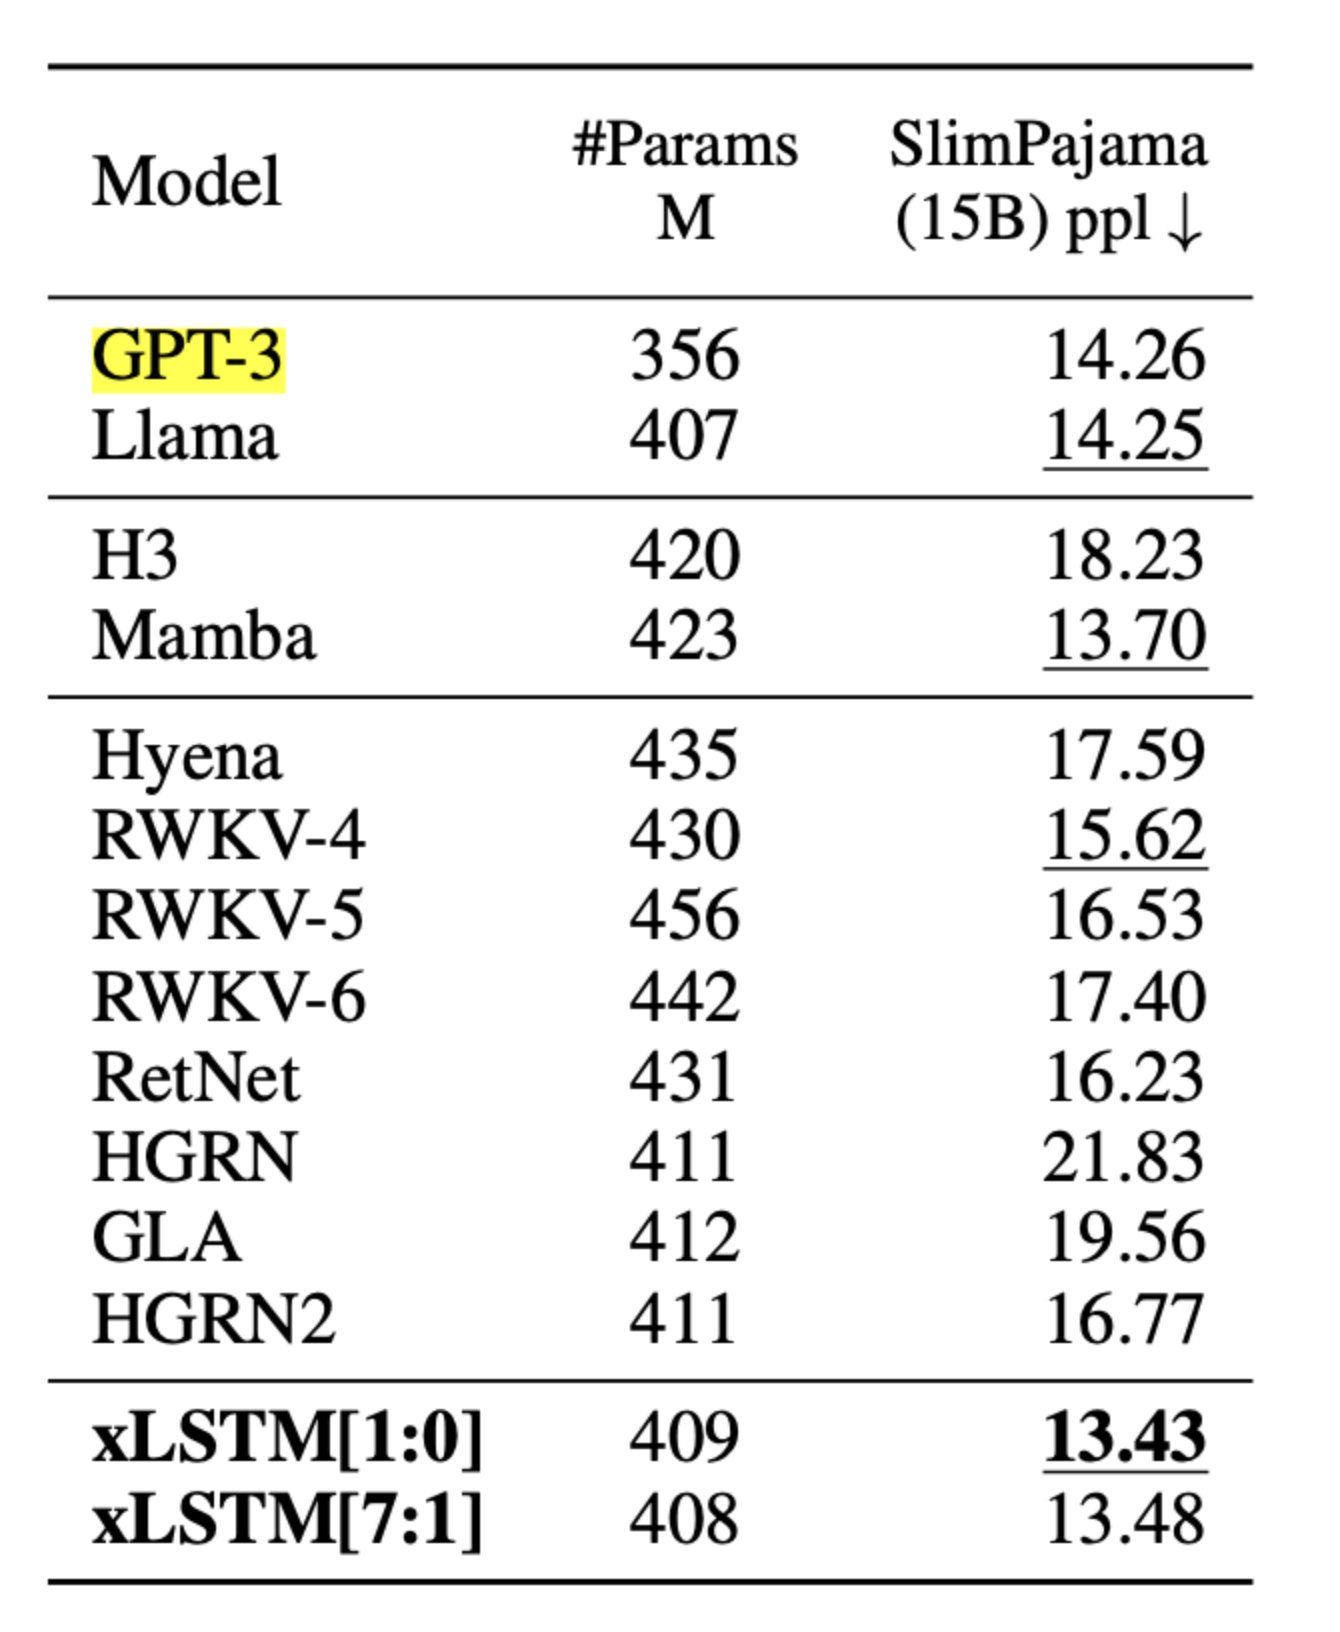

Архитектура xLSTM – **новый виток Deep Learning и NLP**, она обладает большим потенциалом.

> Разработка xLSTM сопровождается целью создать **конкурентоспособную европейскую технологию**, чтобы бросить вызов доминированию американских и азиатских компаний в области больших языковых моделей

> Сегодня наиболее распространены модели в модифицированных вариантах архитектуры Transformer, однако исследования в области гибридных подходов к обработки последовательностей **продолжаются**

> xLSTM может оказать влияние не на замену универсальных чат-ботов, а на создание специфических приложений со сверхдлинными контекстами (научный анализ, анализ кода, сложное планирование) – **всегда выбирайте конкретную архитектуру под конкретную задачу**
